In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/energy_features_2019.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8760 non-null   object 
 1   hour         8760 non-null   int64  
 2   avg_energy   8760 non-null   float64
 3   temperature  8760 non-null   float64
 4   humidity     8760 non-null   float64
 5   pressure     8760 non-null   float64
 6   is_weekend   8760 non-null   int64  
 7   is_holiday   8760 non-null   int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 547.6+ KB


In [4]:
df.head(5)

,date,hour,avg_energy,temperature,humidity,pressure,is_weekend,is_holiday
0,2019-01-01,0,1.2825,2.0,80.0,103.12,0,1
1,2019-01-01,1,1.4725,2.0,80.0,103.12,0,1
2,2019-01-01,2,1.1825,1.6,82.0,103.08,0,1
3,2019-01-01,3,1.0875,1.9,79.0,103.12,0,1
4,2019-01-01,4,1.0775,1.9,82.0,103.13,0,1


In [5]:
sample = df.iloc[:48][['avg_energy', 'temperature', 'humidity',
    'pressure', 'is_weekend', 'is_holiday']].values

In [6]:
print(sample.shape)
print(sample[:3])

(48, 6)
[[  1.2825   2.      80.     103.12     0.       1.    ]
 [  1.4725   2.      80.     103.12     0.       1.    ]
 [  1.1825   1.6     82.     103.08     0.       1.    ]]


In [7]:
type(sample)

numpy.ndarray

In [8]:
sample_t = torch.tensor(sample)

In [9]:
sample_t = sample_t.float()

In [10]:
sample_t.dtype

torch.float32

In [11]:
sample_t = sample_t.unsqueeze(0)
sample_t.shape

torch.Size([1, 48, 6])

In [12]:
d_model = 8
n_features = 6

embedding_layer = nn.Linear(n_features, d_model, bias = False)

embedded = embedding_layer(sample_t)

print(embedded.shape)

torch.Size([1, 48, 8])


In [13]:
embedding_layer.weight.shape

torch.Size([8, 6])

In [14]:
embedding_layer.weight

Parameter containing:
tensor([[-0.1527,  0.0093, -0.3317,  0.3068,  0.2755, -0.1008],
        [ 0.2674, -0.0883, -0.0866,  0.4057,  0.1399,  0.3010],
        [-0.2034,  0.1384, -0.3725,  0.3600, -0.3416, -0.2162],
        [ 0.1098,  0.1359,  0.0572, -0.1458, -0.1139,  0.1232],
        [-0.0659, -0.1507,  0.0357, -0.2892, -0.0364,  0.2711],
        [ 0.3568,  0.0703, -0.2459,  0.3491, -0.2949, -0.2857],
        [ 0.0037, -0.1950,  0.3001,  0.3547,  0.4069,  0.2770],
        [ 0.2952,  0.2976, -0.3578,  0.4074, -0.2871, -0.2555]],
       requires_grad=True)

In [15]:
embedded[0,:4,5:9]

tensor([[16.6461, 60.4762, 14.1029],
        [16.7139, 60.4769, 14.1590],
        [16.0766, 61.1397, 13.2225],
        [16.8153, 60.1949, 14.3734]], grad_fn=<SliceBackward0>)

In [16]:
T = 48
pe = torch.zeros(T, d_model)

In [17]:
position = torch.arange(0, T).unsqueeze(1).float()

In [18]:
div_term = torch.exp(torch.arange(0,d_model, 2).float() * (-math.log(10000.0)/d_model) )

In [19]:
div_term.shape

torch.Size([4])

In [20]:
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

In [21]:
print(pe.shape)
print(pe[:4]) 

torch.Size([48, 8])
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])


In [22]:
# alternate way
pe2 = torch.zeros(T, d_model)
for t in range(T):
    for i in range(d_model//2):

        denominator = 10000 ** (2*i/d_model)
        pe2[t, 2*i] = math.sin(t / denominator)
        pe2[t, 2*i+1] = math.cos(t / denominator)

print(pe2.shape)
print(pe2[:4])

torch.Size([48, 8])
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9996e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])


In [23]:
print(torch.allclose(pe, pe2))  

False


In [24]:
type(pe2)

torch.Tensor

In [27]:
pe_batch = pe.unsqueeze(0)
x_pos = embedded + pe_batch
print(x_pos.shape)

torch.Size([1, 48, 8])


In [28]:
d_k = 8
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

In [29]:
Q = W_Q(x_pos)   
K = W_K(x_pos)  
V = W_V(x_pos)

In [30]:
print(Q.shape, K.shape, V.shape)

torch.Size([1, 48, 8]) torch.Size([1, 48, 8]) torch.Size([1, 48, 8])


In [31]:
scores = torch.matmul(Q, K.transpose(-2, -1))

In [32]:
scores = scores / math.sqrt(d_k)
weights = F.softmax(scores, dim=-1) 

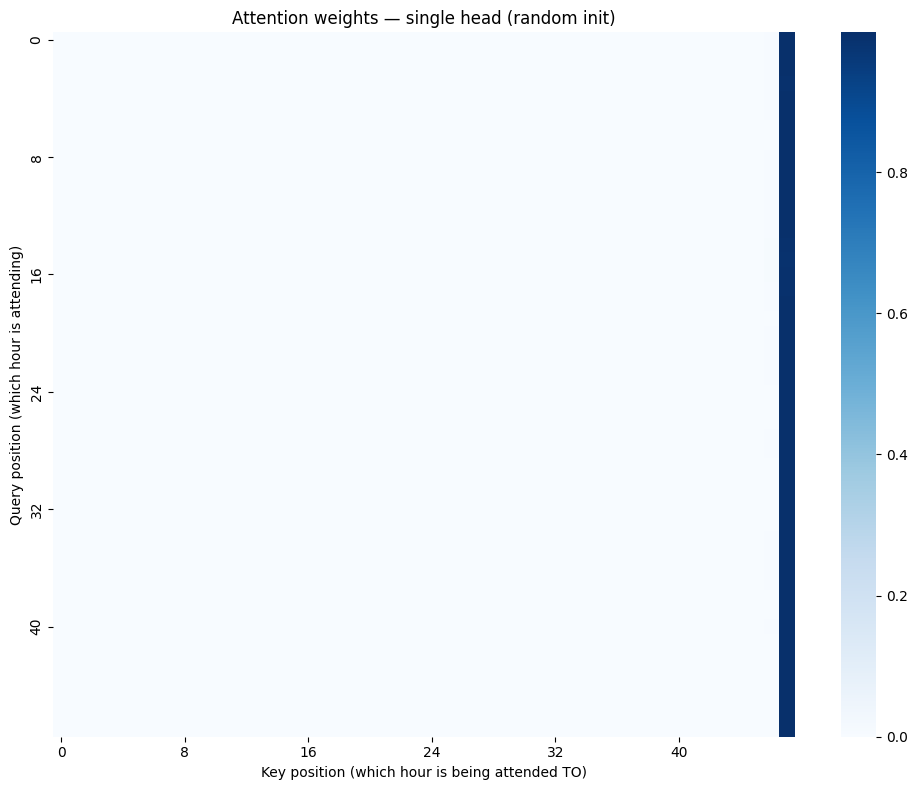

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(weights[0].detach().numpy(), 
            cmap='Blues',
            xticklabels=8, 
            yticklabels=8)
plt.xlabel('Key position (which hour is being attended TO)')
plt.ylabel('Query position (which hour is attending)')
plt.title('Attention weights — single head (random init)')
plt.tight_layout()
plt.savefig('weights.png')

In [37]:
output = torch.matmul(weights, V)   # (1, 48, 8)
print(output.shape)

# look at the output for first 4 timesteps
print(output[0, :4, :].detach())

torch.Size([1, 48, 8])
tensor([[ -1.1274,   8.7268, -11.0024,  -5.1195,  -3.2392,  39.5620,   3.8182,
          -9.9952],
        [ -1.1275,   8.7272, -11.0025,  -5.1196,  -3.2394,  39.5618,   3.8181,
          -9.9947],
        [ -1.1275,   8.7275, -11.0026,  -5.1196,  -3.2396,  39.5616,   3.8181,
          -9.9943],
        [ -1.1276,   8.7280, -11.0028,  -5.1198,  -3.2400,  39.5614,   3.8180,
          -9.9936]])
